In [71]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


project_directory = Path(
    r"C:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents"
    r"\IMDB_WEEK1_SIX\movie-embeddings-project"
)

movies_df = pd.read_csv(
    project_directory
    / "data"
    / "processed"
    / "movies_cleaned.csv"
).reset_index(drop=True)

genres_df = pd.read_csv(
    project_directory
    / "artifacts"
    / "metadata"
    / "movie_genres.csv"
)

genres_df["genres_set"] = genres_df["genres"].apply(lambda x: set(ast.literal_eval(x)))

gte_embeddings = np.load(
    project_directory
    / "artifacts"
    / "embeddings"
    / "gte_modernbert_embeddings.npy"
).astype(np.float32)

gte_embeddings = normalize(
    gte_embeddings,
    norm="l2",
    axis=1,
)

print(gte_embeddings.shape)

from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances,
    manhattan_distances,
)

(9967, 768)


In [76]:
genres_df.columns

Index(['movie_id', 'tmdb_title', 'genre_ids', 'genres', 'genre_count',
       'status', 'dataset_title', 'genres_set'],
      dtype='str')

In [62]:
query_titles = [
    "The Dark Knight",
    "Inception",
    "Toy Story",
    "The Godfather",
    "The Matrix",
    "Titanic",
    "Alien",
    "The Exorcist",
    "Saving Private Ryan",
    "Finding Nemo",
]

In [63]:
comparison_rows = []

for title in query_titles:
    query_index = movies_df[
        movies_df["title"].str.casefold() == title.casefold()
    ].index[0]

    query_embedding = gte_embeddings[
        query_index
    ].reshape(1, -1)

    cosine_scores = cosine_similarity(
        query_embedding,
        gte_embeddings,
    )[0]

    euclidean_scores = euclidean_distances(
        query_embedding,
        gte_embeddings,
    )[0]

    manhattan_scores = manhattan_distances(
        query_embedding,
        gte_embeddings,
    )[0]

    cosine_scores[query_index] = -1
    euclidean_scores[query_index] = np.inf
    manhattan_scores[query_index] = np.inf

    cosine_indices = cosine_scores.argsort()[::-1][:10]
    euclidean_indices = euclidean_scores.argsort()[:10]
    manhattan_indices = manhattan_scores.argsort()[:10]

    cosine_set = set(
        movies_df.iloc[cosine_indices]["movie_id"]
    )

    euclidean_set = set(
        movies_df.iloc[euclidean_indices]["movie_id"]
    )

    manhattan_set = set(
        movies_df.iloc[manhattan_indices]["movie_id"]
    )

    comparison_rows.append(
        {
            "title": title,
            "cosine_euclidean_overlap": len(
                cosine_set & euclidean_set
            ),
            "cosine_manhattan_overlap": len(
                cosine_set & manhattan_set
            ),
            "euclidean_manhattan_overlap": len(
                euclidean_set & manhattan_set
            ),
        }
    )

metric_overlap_df = pd.DataFrame(comparison_rows)

display(metric_overlap_df)

,title,cosine_euclidean_overlap,cosine_manhattan_overlap,euclidean_manhattan_overlap
0,The Dark Knight,10,10,10
1,Inception,10,8,8
2,Toy Story,10,9,9
3,The Godfather,10,7,7
4,The Matrix,10,9,9
5,Titanic,10,6,6
6,Alien,10,9,9
7,The Exorcist,10,10,10
8,Saving Private Ryan,10,9,9
9,Finding Nemo,10,9,9


In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


RANDOM_STATE = 42
k_values = range(2, 13)
silhouette_scores = []

kmeans_evaluation_rows = []



for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
        )

    labels = kmeans.fit_predict(gte_embeddings)

    score = silhouette_score(
        gte_embeddings,
        labels,
        metric="euclidean",
        random_state=RANDOM_STATE,
        )

    silhouette_scores.append(score)

    print(
        f"k={k:} | "
        f"inertia={kmeans.inertia_:,.2f} | "
        f"silhouette={score:.4f}"
        )




k=2 | inertia=4,302.72 | silhouette=0.0277
k=3 | inertia=4,230.05 | silhouette=0.0232
k=4 | inertia=4,183.86 | silhouette=0.0194
k=5 | inertia=4,144.76 | silhouette=0.0194
k=6 | inertia=4,113.37 | silhouette=0.0194
k=7 | inertia=4,087.06 | silhouette=0.0200
k=8 | inertia=4,062.13 | silhouette=0.0186
k=9 | inertia=4,037.82 | silhouette=0.0195
k=10 | inertia=4,017.12 | silhouette=0.0170
k=11 | inertia=3,999.50 | silhouette=0.0171
k=12 | inertia=3,982.70 | silhouette=0.0169


In [74]:
final_k = 7

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20,
)

movies_df["cluster"] = kmeans.fit_predict(gte_embeddings)

movies_df["cluster"].value_counts().sort_index()

cluster
0    1727
1    1391
2    1000
3    1161
4    1733
5    1733
6    1222
Name: count, dtype: int64

In [77]:
cluster_genres_df = movies_df[
    ["movie_id", "title", "cluster"]
].merge(
    genres_df[["movie_id", "genre_set"]],
    on="movie_id",
    how="left",
)

KeyError: "['genre_set'] not in index"

In [67]:
import numpy as np


representative_rows = []

for cluster_id in range(7):
    cluster_indices = np.flatnonzero(movies_df["cluster"] == cluster_id)
    cluster_embeddings = gte_embeddings[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)

    similarities = cluster_embeddings @ centroid

    top_positions = np.argsort(similarities)[::-1][:5]
    top_indices = cluster_indices[top_positions]

    for rank, movie_index in enumerate(top_indices, start=1):
        representative_rows.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "title": movies_df.iloc[movie_index]["title"],
                "overview": movies_df.iloc[movie_index]["overview"],
                "centroid_similarity": similarities[top_positions[rank - 1]],
            }
        )

representative_movies = pd.DataFrame(representative_rows)

display(representative_movies)

,cluster,rank,title,overview,centroid_similarity
0,0,1,Black Box,After losing his wife and his memory in a car ...,0.835614
1,0,2,The Eighth Day,"Georges has Down syndrome, living at a mental-...",0.832172
2,0,3,Kabhi Khushi Kabhie Gham,Years after his father disowns his adopted bro...,0.831391
3,0,4,The Do-Over,The life of a bank manager is turned upside do...,0.831089
4,0,5,About Schmidt,A recently retired man embarks on a journey to...,0.828280
5,1,1,"The Boy, the Mole, the Fox and the Horse","The unlikely friendship of a boy, a mole, a fo...",0.835834
6,1,2,The Package,When a group of teenagers goes on a spring bre...,0.827999
7,1,3,House of Wax,A group of unwitting teens are stranded near a...,0.824970
8,1,4,Free Willy,When maladjusted orphan Jesse vandalizes a the...,0.824795
9,1,5,Mandibles,When two simple-minded best friends find a gia...,0.823634


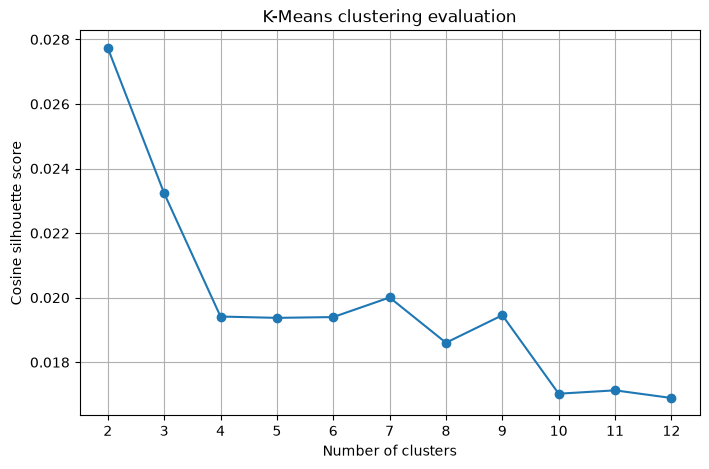

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Cosine silhouette score")
plt.title("K-Means clustering evaluation")
plt.xticks(list(k_values))
plt.grid()
plt.show()

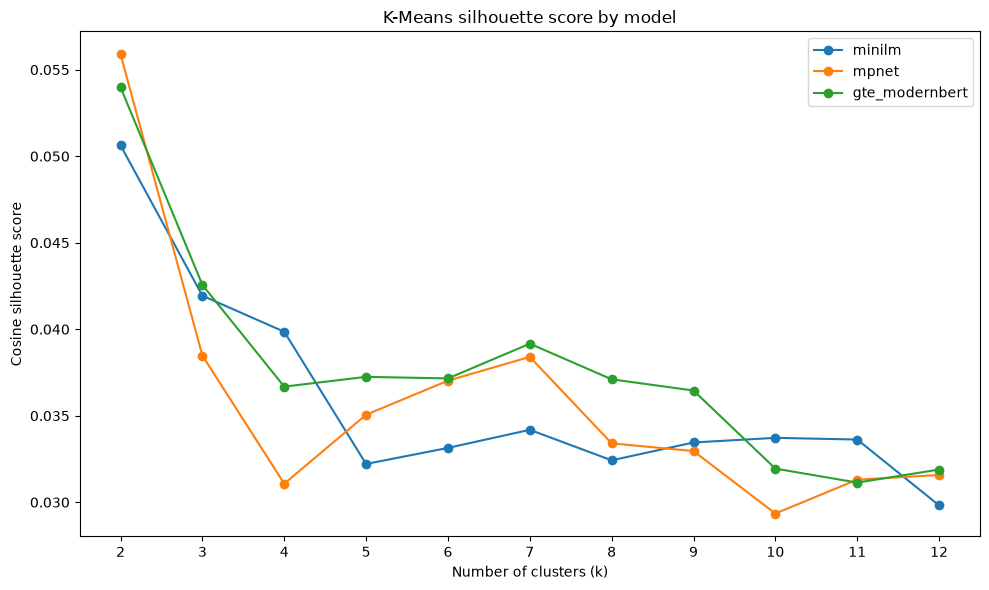

In [16]:
plt.figure(figsize=(10, 6))

for model_name in embeddings:
    model_results = kmeans_evaluation_df[
        kmeans_evaluation_df["model"] == model_name
    ]

    plt.plot(
        model_results["k"],
        model_results["silhouette_score"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Number of clusters (k)")
plt.ylabel("Cosine silhouette score")
plt.title("K-Means silhouette score by model")
plt.xticks(list(K_VALUES))
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
for model_name, embedding_matrix in embeddings.items():
    kmeans = KMeans(
        n_clusters=2,
        n_init=20,
        random_state=42,
    )

    labels = kmeans.fit_predict(embedding_matrix)

    cosine_score = silhouette_score(
        embedding_matrix,
        labels,
        metric="cosine",
        sample_size=min(2_000, len(embedding_matrix)),
        random_state=42,
    )

    euclidean_score = silhouette_score(
        embedding_matrix,
        labels,
        metric="euclidean",
        sample_size=min(2_000, len(embedding_matrix)),
        random_state=42,
    )

    print(
        model_name,
        f"cosine={cosine_score:.4f}",
        f"euclidean={euclidean_score:.4f}",
    )

minilm cosine=0.0506 euclidean=0.0261
mpnet cosine=0.0559 euclidean=0.0292
gte_modernbert cosine=0.0540 euclidean=0.0278


In [39]:
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize


# Ako već imaš dictionary embeddings
gte_embeddings = embeddings["gte_modernbert"]

# Osiguraj L2 normalizaciju
x_gte = normalize(gte_embeddings, norm="l2", axis=1)

kmeans_gte_7 = KMeans(
    n_clusters=7,
    n_init=20,
    max_iter=300,
    random_state=42,
)

gte_labels_7 = kmeans_gte_7.fit_predict(x_gte)

cosine_silhouette = silhouette_score(
    x_gte,
    gte_labels_7,
    metric="cosine",
)

euclidean_silhouette = silhouette_score(
    x_gte,
    gte_labels_7,
    metric="euclidean",
)

cluster_sizes = np.bincount(gte_labels_7)

print(f"Cosine silhouette: {cosine_silhouette:.4f}")
print(f"Euclidean silhouette: {euclidean_silhouette:.4f}")
print(f"Cluster sizes: {cluster_sizes}")
print(
    "Cluster percentages:",
    np.round(100 * cluster_sizes / len(gte_labels_7), 2),
)

Cosine silhouette: 0.0385
Euclidean silhouette: 0.0199
Cluster sizes: [1730 1385 1009 1171 1722 1731 1219]
Cluster percentages: [17.36 13.9  10.12 11.75 17.28 17.37 12.23]


In [42]:
import numpy as np


representative_rows = []

for cluster_id in range(7):
    cluster_indices = np.flatnonzero(gte_labels_7 == cluster_id)
    cluster_embeddings = x_gte[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)
    centroid = centroid / np.linalg.norm(centroid)

    similarities = cluster_embeddings @ centroid

    top_positions = np.argsort(similarities)[::-1][:5]
    top_indices = cluster_indices[top_positions]

    for rank, movie_index in enumerate(top_indices, start=1):
        representative_rows.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "title": movies_df.iloc[movie_index]["title"],
                "overview": movies_df.iloc[movie_index]["overview"],
                "centroid_similarity": similarities[top_positions[rank - 1]],
            }
        )

representative_movies = pd.DataFrame(representative_rows)

display(representative_movies)

c:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents\IMDB_WEEK1_SIX\.venv\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,cluster,rank,title,overview,centroid_similarity
0,0,1,Black Box,After losing his wife and his memory in a car ...,0.835449
1,0,2,The Eighth Day,"Georges has Down syndrome, living at a mental-...",0.832031
2,0,3,The Do-Over,The life of a bank manager is turned upside do...,0.831543
3,0,4,Kabhi Khushi Kabhie Gham,Years after his father disowns his adopted bro...,0.831543
4,0,5,About Schmidt,A recently retired man embarks on a journey to...,0.828613
5,1,1,"The Boy, the Mole, the Fox and the Horse","The unlikely friendship of a boy, a mole, a fo...",0.835938
6,1,2,The Package,When a group of teenagers goes on a spring bre...,0.827637
7,1,3,Free Willy,When maladjusted orphan Jesse vandalizes a the...,0.824707
8,1,4,House of Wax,A group of unwitting teens are stranded near a...,0.824707
9,1,5,Mandibles,When two simple-minded best friends find a gia...,0.823242


Explained variance: [0.03971357 0.02990147]
Total explained variance: 0.06961504103170679


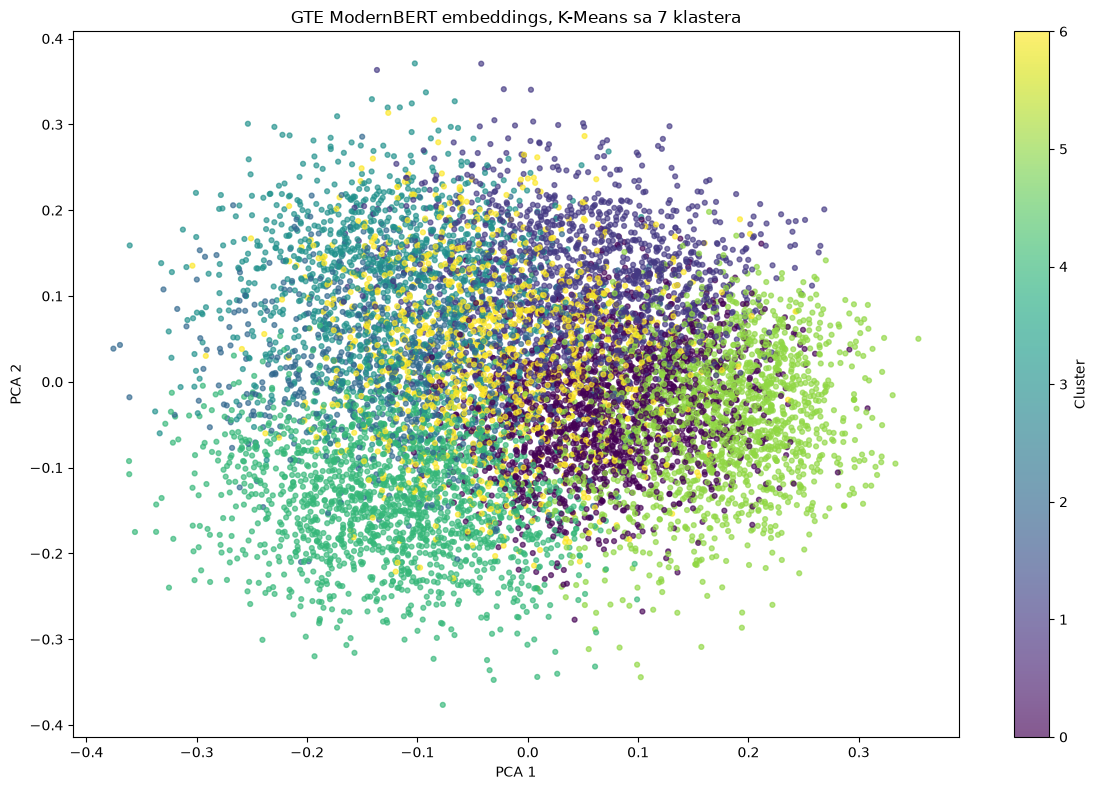

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize


# GTE embeddingi
x_gte = normalize(
    embeddings["gte_modernbert"],
    norm="l2",
    axis=1,
)

# PCA redukcija na 2 dimenzije samo za vizualizaciju
pca_2d = PCA(
    n_components=2,
    random_state=42,
)

gte_pca_2d = pca_2d.fit_transform(x_gte)

plot_df = pd.DataFrame(
    {
        "pca_1": gte_pca_2d[:, 0],
        "pca_2": gte_pca_2d[:, 1],
        "cluster": gte_labels_7,
        "title": movies_df["title"].to_numpy(),
        "overview": movies_df["overview"].to_numpy(),
    }
)

print(
    "Explained variance:",
    pca_2d.explained_variance_ratio_,
)

print(
    "Total explained variance:",
    pca_2d.explained_variance_ratio_.sum(),
)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df["pca_1"],
    plot_df["pca_2"],
    c=plot_df["cluster"],
    s=12,
    alpha=0.65,
)

plt.colorbar(scatter, label="Cluster")
plt.title("GTE ModernBERT embeddings, K-Means sa 7 klastera")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()

Cosine silhouette: 0.0387
Cluster sizes: [1727 1391 1000 1161 1733 1733 1222]
Cluster percentages: [17.33 13.96 10.03 11.65 17.39 17.39 12.26]
Total explained variance: 0.0696


,cluster,rank,movie_position,title,overview,centroid_similarity
0,0,1,6686,Black Box,After losing his wife and his memory in a car ...,0.835614
1,0,2,1937,The Eighth Day,"Georges has Down syndrome, living at a mental-...",0.832172
2,0,3,854,Kabhi Khushi Kabhie Gham,Years after his father disowns his adopted bro...,0.831391
3,0,4,9519,The Do-Over,The life of a bank manager is turned upside do...,0.831089
4,0,5,4263,About Schmidt,A recently retired man embarks on a journey to...,0.828280
...,...,...,...,...,...,...
65,6,6,9307,Annabelle,A couple begins to experience terrifying super...,0.847532
66,6,7,4430,Bird Box,Five years after an ominous unseen presence dr...,0.846894
67,6,8,8494,The Silence,With the world under attack by deadly creature...,0.846093
68,6,9,7768,The Empty Man,"On the trail of a missing girl, an ex-cop come...",0.845339


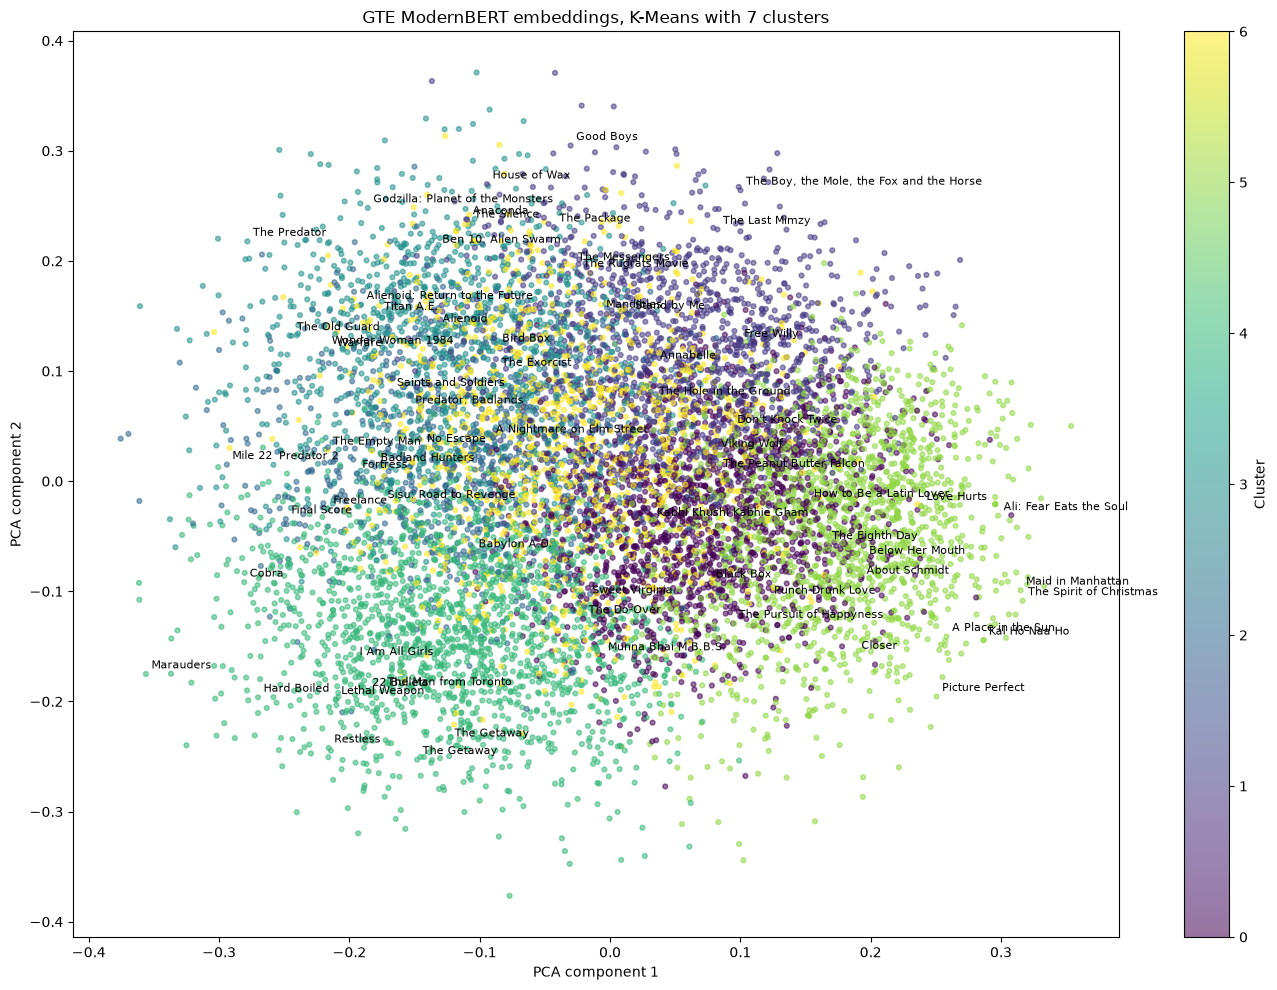

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize


# 1. Load and normalize GTE embeddings
x_gte = normalize(
    embeddings["gte_modernbert"].astype(np.float32),
    norm="l2",
    axis=1,
)

assert len(movies_df) == len(x_gte)


# 2. K-Means with 7 clusters
kmeans_gte_7 = KMeans(
    n_clusters=7,
    n_init=20,
    max_iter=300,
    random_state=42,
)

gte_labels_7 = kmeans_gte_7.fit_predict(x_gte)

cosine_silhouette = silhouette_score(
    x_gte,
    gte_labels_7,
    metric="cosine",
)

cluster_sizes = np.bincount(gte_labels_7)

print(f"Cosine silhouette: {cosine_silhouette:.4f}")
print(f"Cluster sizes: {cluster_sizes}")
print(
    "Cluster percentages:",
    np.round(100 * cluster_sizes / len(gte_labels_7), 2),
)


# 3. PCA only for 2D visualization
pca = PCA(
    n_components=2,
    random_state=42,
)

x_gte_pca = pca.fit_transform(x_gte)

print(
    f"Total explained variance: "
    f"{pca.explained_variance_ratio_.sum():.4f}"
)


# 4. Find ten representative movies per cluster
representative_movies = []

for cluster_id in range(7):
    cluster_indices = np.flatnonzero(
        gte_labels_7 == cluster_id
    )

    cluster_embeddings = x_gte[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)
    centroid_norm = np.linalg.norm(centroid)

    if centroid_norm > 0:
        centroid = centroid / centroid_norm

    similarities = cluster_embeddings @ centroid

    top_positions = np.argsort(similarities)[::-1][:10]
    top_movie_indices = cluster_indices[top_positions]

    for rank, movie_index in enumerate(
        top_movie_indices,
        start=1,
    ):
        representative_movies.append(
            {
                "cluster": cluster_id,
                "rank": rank,
                "movie_position": int(movie_index),
                "title": movies_df.iloc[movie_index]["title"],
                "overview": movies_df.iloc[movie_index]["overview"],
                "centroid_similarity": float(
                    similarities[top_positions[rank - 1]]
                ),
            }
        )

representative_movies_df = pd.DataFrame(
    representative_movies
)

display(representative_movies_df)
representative_movies_df.to_csv("artifacts/metrics/zanrovi.csv", index=False)

# 5. Plot all movies and label representatives
plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    x_gte_pca[:, 0],
    x_gte_pca[:, 1],
    c=gte_labels_7,
    s=12,
    alpha=0.55,
)

for _, movie in representative_movies_df.iterrows():
    movie_position = int(movie["movie_position"])

    plt.annotate(
        movie["title"],
        (
            x_gte_pca[movie_position, 0],
            x_gte_pca[movie_position, 1],
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

plt.colorbar(scatter, label="Cluster")
plt.title("GTE ModernBERT embeddings, K-Means with 7 clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.tight_layout()
plt.show()